**Assignment-8: Logistic Regression**

Objective: Implement Logistic Regression, classify a dataset, visualize decision boundary, and evaluate performance.

**# Step 1: Import required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**# Step 2: Create dataset**

In [2]:

data = {
    'Hours': [1,2,3,4,5,6,7,8,9,10],
    'Pass':  [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

print(df)

   Hours  Pass
0      1     0
1      2     0
2      3     0
3      4     0
4      5     1
5      6     1
6      7     1
7      8     1
8      9     1
9     10     1


**# Step 3: Select input (X) and output (y)**

In [3]:
X = df[['Hours']]
y = df['Pass']

**# Step 4: Split data into training and testing sets**

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:")
print(X_train)

print("Testing Data:")
print(X_test)

Training Data:
   Hours
5      6
0      1
7      8
2      3
9     10
4      5
3      4
6      7
Testing Data:
   Hours
8      9
1      2


**# Step 5: Create Logistic Regression model**

In [5]:

model = LogisticRegression()

**# Step 6: Train the model**

In [6]:

model.fit(X_train, y_train)

LogisticRegression()

**# Step 7: Predict test data**

In [7]:

y_pred = model.predict(X_test)

print("Predicted Classes:", y_pred)

Predicted Classes: [1 0]


**# Step 8: Predict probability**

In [8]:

y_prob = model.predict_proba(X_test)

print("Prediction Probabilities:")
print(y_prob)

Prediction Probabilities:
[[0.0060152  0.9939848 ]
 [0.93844742 0.06155258]]


**# Step 9: Evaluate model performance**

In [9]:

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", report)

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



# Step 10: Visualize decision boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


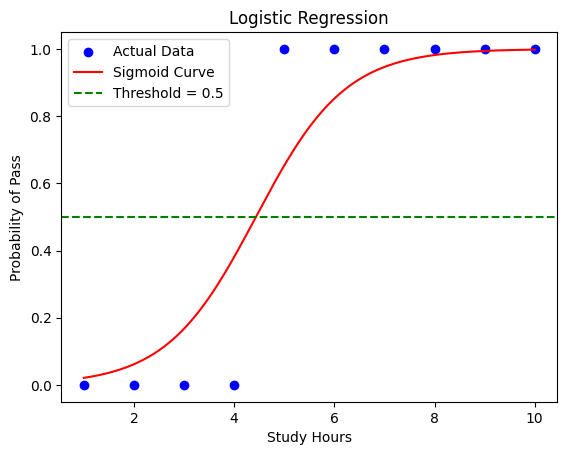

In [10]:

X_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
y_range = model.predict_proba(X_range)[:,1]

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_range, y_range, color='red', label='Sigmoid Curve')
plt.axhline(y=0.5, color='green', linestyle='--', label='Threshold = 0.5')

plt.xlabel("Study Hours")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression")
plt.legend()
plt.show()